<a href="https://colab.research.google.com/github/Lordpanda2003/CNN_ECE_ThiefDetect_2025/blob/main/TP_CNN_Detection_Voleurs_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GROUPE 7

## Membre:

    Parfait-Junior MONEZE​

    Luc Bernard BANAG LIBITE​​

    Abdoul Rahime Mohamed BARRO​​

    Guy SOUMELONG EBEMBO​​
ECE Paris, ING4 Cyber

# TP - Detection de Comportements Suspects avec CNN
### Dataset : Thief Detection Dataset (Kaggle)

- dataset (`janstylewis7/thief-detection-dataset`)
- Transfer Learning MobileNetV2 pre-entraine ImageNet (CNN Keras)
- Augmentation conservative adaptee aux images de surveillance
- Splits natifs du dataset conserves
- Inference video par resize frame entiere + chargement depuis Drive

## Etape 1 - Installation et imports

In [ ]:
!pip install kagglehub tensorflow opencv-python-headless scikit-learn matplotlib numpy Pillow -q
print("Dependances installees")

Dependances installees


In [ ]:
import os, warnings
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU disponible : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow : 2.19.0
GPU disponible : True


## Etape 2 - Telechargement et exploration du dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("janstylewis7/thief-detection-dataset")
print("Chemin du dataset :", path)

for root, dirs, files in os.walk(path):
    dirs.sort()
    level = root.replace(path, '').count(os.sep)
    if level > 2: continue
    indent = '  ' * level
    n = len(files)
    print(f"{indent}{os.path.basename(root)}/  ({n} fichiers)")
    if level == 2 and files:
        sub = '  ' * (level + 1)
        for f in sorted(files)[:3]:
            print(f"{sub}{f}")
        if n > 3:
            print(f"{sub}... ({n-3} autres)")

Using Colab cache for faster access to the 'thief-detection-dataset' dataset.
Chemin du dataset : /kaggle/input/thief-detection-dataset
thief-detection-dataset/  (3 fichiers)
  test/  (0 fichiers)
    images/  (227 fichiers)
      frame100_jpg.rf.c9d8c3ecf2c7ac5b3fdb8b8f83c5b2f4.jpg
      frame101_jpg.rf.d9b2b60f7ac1f9d0388b6a5c6687a622.jpg
      frame103_jpg.rf.9386b55acacd907e200dc93e49c8a4e8.jpg
      ... (224 autres)
    labels/  (227 fichiers)
      frame100_jpg.rf.c9d8c3ecf2c7ac5b3fdb8b8f83c5b2f4.txt
      frame101_jpg.rf.d9b2b60f7ac1f9d0388b6a5c6687a622.txt
      frame103_jpg.rf.9386b55acacd907e200dc93e49c8a4e8.txt
      ... (224 autres)
  train/  (0 fichiers)
    images/  (1887 fichiers)
      WhatsApp-Image-2024-11-20-at-10-03-10-PM-2-_jpeg.rf.2911db6cea1ac447fec1a2f9e3471695.jpg
      WhatsApp-Image-2024-11-20-at-10-03-10-PM-3-_jpeg.rf.fbb06733784516e801214d5ba4c6e0a8.jpg
      WhatsApp-Image-2024-11-20-at-10-03-11-PM-2-_jpeg.rf.be9e0e4b9c5b5cf9dc573abc11caa357.jpg
      ... 

In [ ]:
# Configuration — classes du premier dataset
# 8 classes : car, face hiding, gun, human,
#             human in hurry, human_brakingdoor, human_lockunlocking, weapon

YOLO_CLASSES = ['car', 'face hiding', 'gun', 'human',
                 'human in hurry', 'human_brakingdoor',
                 'human_lockunlocking', 'weapon']

SUSPECT_CLASS_IDS = {1, 2, 4, 5, 6, 7}  # tout sauf human(3) et car(0)
NORMAL_CLASS_IDS  = {0, 3}

IMG_SIZE = 96  # entree MobileNetV2 (minimum 96x96)

# Detection des splits
def find_splits(base_path):
    splits = {}
    for split_name in ['train', 'valid', 'test', 'Train', 'Valid', 'Test']:
        img_d = os.path.join(base_path, split_name, 'images')
        lbl_d = os.path.join(base_path, split_name, 'labels')
        if os.path.isdir(img_d) and os.path.isdir(lbl_d):
            imgs = [f for f in os.listdir(img_d)
                    if f.lower().endswith(('.jpg','.png','.jpeg'))]
            lbls = [f for f in os.listdir(lbl_d) if f.endswith('.txt')]
            if imgs:
                splits[split_name.lower()] = {
                    'img_dir': img_d, 'lbl_dir': lbl_d,
                    'n_images': len(imgs), 'n_labels': len(lbls)
                }
    # Fallback : chercher images/labels a la racine
    if not splits:
        for root, dirs, files in os.walk(base_path):
            imgs = [f for f in files if f.lower().endswith(('.jpg','.png','.jpeg'))]
            if len(imgs) > 10:
                parent = os.path.dirname(root)
                lbl_d  = os.path.join(parent, 'labels')
                if not os.path.isdir(lbl_d):
                    lbl_d = root.replace('images', 'labels')
                if os.path.isdir(lbl_d):
                    key = os.path.basename(os.path.dirname(root))
                    splits[key] = {'img_dir': root, 'lbl_dir': lbl_d,
                                   'n_images': len(imgs), 'n_labels': 0}
    return splits

SPLITS = find_splits(path)
print(f"{len(SPLITS)} split(s) detecte(s) :")
for name, s in SPLITS.items():
    print(f"  [{name}]  {s['n_images']} images  {s['n_labels']} labels")

print("\nClasses suspectes :", [YOLO_CLASSES[i] for i in SUSPECT_CLASS_IDS])
print("Classes normales  :", [YOLO_CLASSES[i] for i in NORMAL_CLASS_IDS])

3 split(s) detecte(s) :
  [train]  1887 images  1887 labels
  [valid]  250 images  250 labels
  [test]  227 images  227 labels

Classes suspectes : ['face hiding', 'gun', 'human in hurry', 'human_brakingdoor', 'human_lockunlocking', 'weapon']
Classes normales  : ['car', 'human']


Distribution des annotations :
  [normal ]  human                      2673
  [SUSPECT]  weapon                      313
  [SUSPECT]  human_brakingdoor           265
  [SUSPECT]  human_lockunlocking         207
  [normal ]  car                         205
  [SUSPECT]  human in hurry              154
  [SUSPECT]  face hiding                 117
  [SUSPECT]  gun                         104


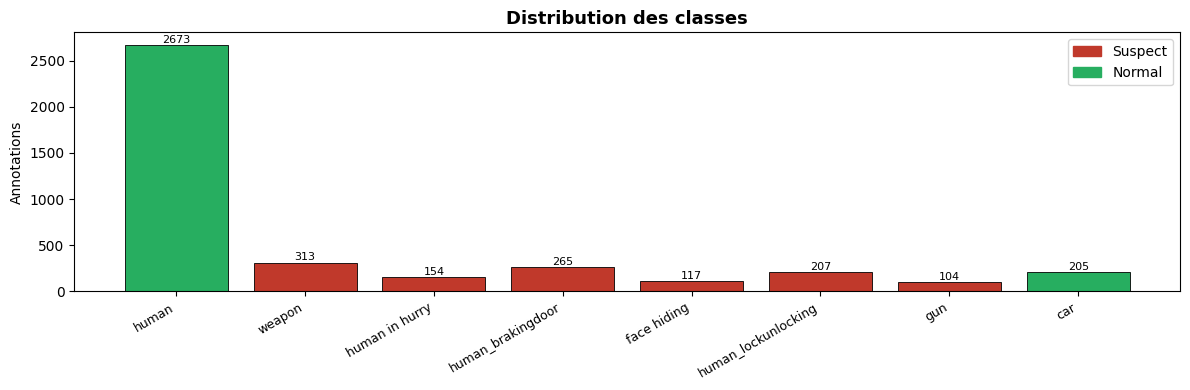

In [ ]:
# Distribution des annotations
class_counts = Counter()
for s in SPLITS.values():
    for lf in os.listdir(s['lbl_dir']):
        if not lf.endswith('.txt'): continue
        with open(os.path.join(s['lbl_dir'], lf)) as f:
            for line in f:
                p = line.strip().split()
                if len(p) >= 5:
                    cls_id = int(p[0])
                    if cls_id < len(YOLO_CLASSES):
                        class_counts[YOLO_CLASSES[cls_id]] += 1

print("Distribution des annotations :")
for cls, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
    tag = "SUSPECT" if YOLO_CLASSES.index(cls) in SUSPECT_CLASS_IDS else "normal "
    print(f"  [{tag}]  {cls:<25} {cnt:>5}")

fig, ax = plt.subplots(figsize=(12, 4))
classes_plot = list(class_counts.keys())
counts_plot  = [class_counts[c] for c in classes_plot]
colors_plot  = ['#c0392b' if YOLO_CLASSES.index(c) in SUSPECT_CLASS_IDS
                else '#27ae60' for c in classes_plot]
bars = ax.bar(classes_plot, counts_plot, color=colors_plot,
              edgecolor='black', linewidth=0.6)
ax.set_xticklabels(classes_plot, rotation=30, ha='right', fontsize=9)
ax.set_title("Distribution des classes", fontweight='bold', fontsize=13)
ax.set_ylabel("Annotations")
for bar, cnt in zip(bars, counts_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha='center', va='bottom', fontsize=8)
legend_elems = [mpatches.Patch(color='#c0392b', label='Suspect'),
                mpatches.Patch(color='#27ae60', label='Normal')]
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.show()

## Etape 3 - Extraction des crops

Les splits natifs du dataset sont conserves separement pour eviter toute fuite de donnees.

In [ ]:
CROPS_BASE = "/content/crops"
MIN_CROP   = 30   # filtrer les bbox trop petites (amelioration v5)
PADDING    = 0.05

def extract_crops(img_dir, lbl_dir, out_dir, img_size=96, pad=0.05, min_crop=30):
    os.makedirs(f"{out_dir}/suspect", exist_ok=True)
    os.makedirs(f"{out_dir}/normal",  exist_ok=True)
    n_suspect = n_normal = n_skipped = 0

    for lbl_fname in [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]:
        stem = os.path.splitext(lbl_fname)[0]
        img_path = None
        for ext in ('.jpg', '.jpeg', '.png', '.JPG', '.PNG'):
            c = os.path.join(img_dir, stem + ext)
            if os.path.exists(c):
                img_path = c; break
        if img_path is None: continue

        img = cv2.imread(img_path)
        if img is None: continue
        H, W = img.shape[:2]

        with open(os.path.join(lbl_dir, lbl_fname)) as f:
            for i, line in enumerate(f):
                p = line.strip().split()
                if len(p) < 5: continue
                cls_id = int(p[0])
                if cls_id >= len(YOLO_CLASSES): continue

                cx, cy, bw, bh = map(float, p[1:5])
                bw2 = bw*(1+pad); bh2 = bh*(1+pad)
                x1 = max(0, int((cx-bw2/2)*W))
                y1 = max(0, int((cy-bh2/2)*H))
                x2 = min(W, int((cx+bw2/2)*W))
                y2 = min(H, int((cy+bh2/2)*H))

                if (x2-x1) < min_crop or (y2-y1) < min_crop:
                    n_skipped += 1; continue

                crop = cv2.resize(img[y1:y2, x1:x2], (img_size, img_size))
                label = 'suspect' if cls_id in SUSPECT_CLASS_IDS else 'normal'
                cv2.imwrite(f"{out_dir}/{label}/{stem}_{i}.jpg", crop)
                if label == 'suspect': n_suspect += 1
                else: n_normal += 1

    return n_suspect, n_normal, n_skipped

print("Extraction en cours...")
split_stats = {}
for split_name, s in SPLITS.items():
    out = os.path.join(CROPS_BASE, split_name)
    ns, nn, nsk = extract_crops(s['img_dir'], s['lbl_dir'], out, IMG_SIZE, PADDING, MIN_CROP)
    split_stats[split_name] = {'suspect': ns, 'normal': nn, 'skipped': nsk}
    print(f"  [{split_name}]  suspect={ns}  normal={nn}  ignores={nsk}")

total = sum(v['suspect']+v['normal'] for v in split_stats.values())
print(f"\nTotal crops : {total}")

Extraction en cours...
  [train]  suspect=963  normal=2032  ignores=260
  [valid]  suspect=76  normal=264  ignores=72
  [test]  suspect=20  normal=347  ignores=4

Total crops : 3702


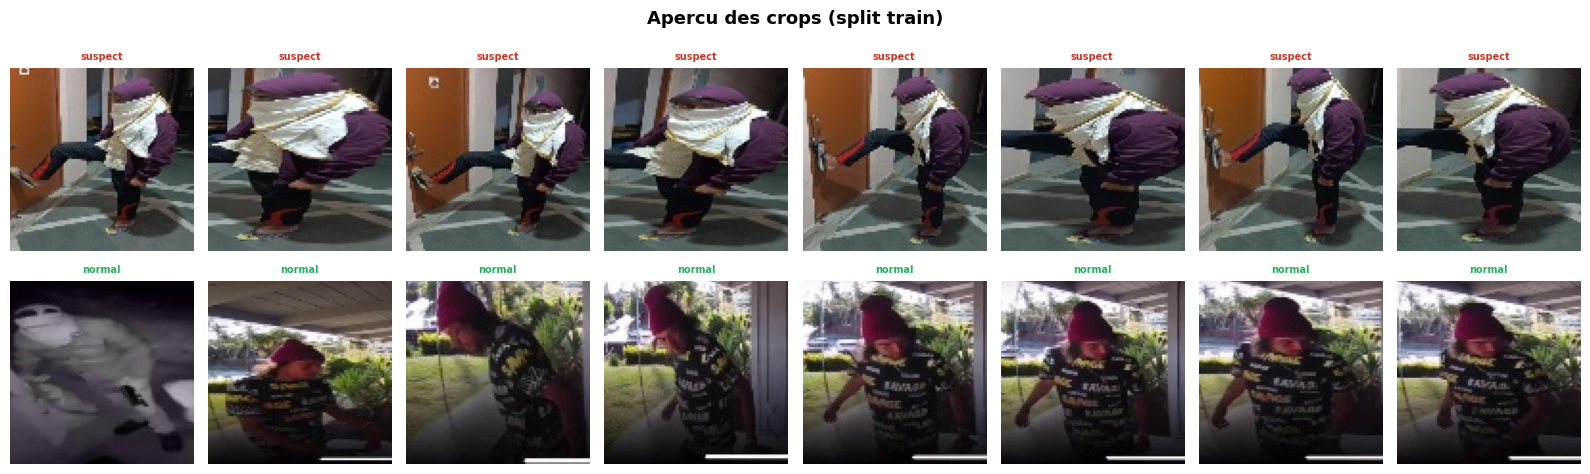

In [ ]:
# Apercu
split_preview = list(SPLITS.keys())[0]
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle(f"Apercu des crops (split {split_preview})", fontsize=13, fontweight='bold')
for row, (label, color) in enumerate([('suspect','#c0392b'),('normal','#27ae60')]):
    ldir = f"{CROPS_BASE}/{split_preview}/{label}"
    if not os.path.isdir(ldir):
        continue
    files = sorted(os.listdir(ldir))[:8]
    for j in range(8):
        ax = axes[row][j]
        if j < len(files):
            img = cv2.cvtColor(cv2.imread(os.path.join(ldir, files[j])),
                               cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(label, fontsize=7, color=color, fontweight='bold')
        ax.axis('off')
plt.tight_layout()
plt.show()

## Etape 4 - Chargement des splits

In [ ]:
def load_split(split_dir, img_size=96):
    X, y = [], []
    for label, idx in [('normal', 0), ('suspect', 1)]:
        folder = os.path.join(split_dir, label)
        if not os.path.isdir(folder): continue
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg','.png','.jpeg'))]
        for fname in files:
            img = cv2.imread(os.path.join(folder, fname))
            if img is None: continue
            img = cv2.resize(img, (img_size, img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(img.astype(np.float32) / 255.0)
            y.append(idx)
    return np.array(X), np.array(y)

print("Chargement...")
X_tr,   y_tr   = load_split(f"{CROPS_BASE}/train", IMG_SIZE)

# Validation : prendre valid si dispo, sinon test
val_split = 'valid' if 'valid' in SPLITS else 'test'
X_val,  y_val  = load_split(f"{CROPS_BASE}/{val_split}", IMG_SIZE)

# Test : prendre test si dispo, sinon valid
test_split = 'test' if 'test' in SPLITS else val_split
X_test, y_test = load_split(f"{CROPS_BASE}/{test_split}", IMG_SIZE)

for name, X, y in [("Train", X_tr, y_tr),
                    (f"Valid ({val_split})", X_val, y_val),
                    (f"Test  ({test_split})", X_test, y_test)]:
    u, c = np.unique(y, return_counts=True)
    dist = {['normal','suspect'][int(ui)]: int(ci) for ui, ci in zip(u, c)}
    print(f"  {name:<18} : {len(X):>5} samples  {dist}")

cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weight = {int(i): float(w) for i, w in enumerate(cw)}
print(f"\nClass weights : {class_weight}")

Chargement...
  Train              :  2995 samples  {'normal': 2032, 'suspect': 963}
  Valid (valid)      :   340 samples  {'normal': 264, 'suspect': 76}
  Test  (test)       :   367 samples  {'normal': 347, 'suspect': 20}

Class weights : {0: 0.7369586614173228, 1: 1.555036344755971}


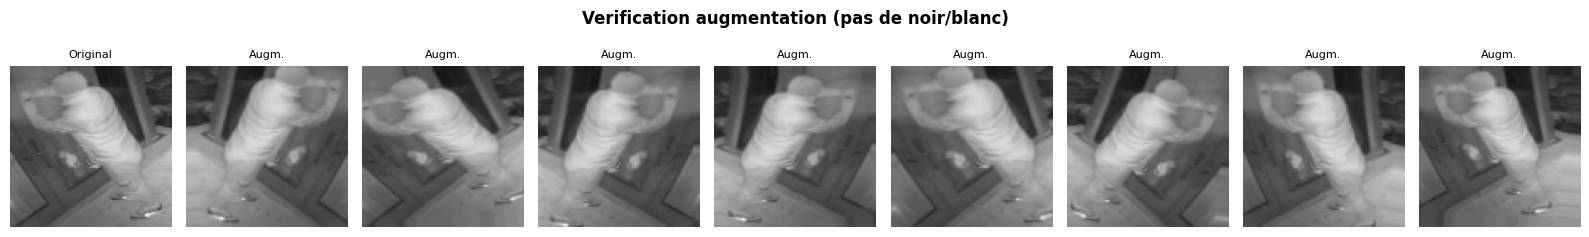

Augmentation configuree


In [ ]:
# Augmentation conservative pour images de surveillance
# Pas de brightness_range ni channel_shift — evite le noir/blanc artificiel
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.10,
    fill_mode='nearest'
)

# Verification visuelle — les images doivent rester reconnaissables
sample_idx = np.where(y_tr == 1)[0][0]
sample = X_tr[sample_idx][np.newaxis]
gen = datagen.flow(sample, batch_size=1)

fig, axes = plt.subplots(1, 9, figsize=(16, 2.5))
axes[0].imshow(sample[0]); axes[0].set_title("Original", fontsize=8); axes[0].axis('off')
for ax in axes[1:]:
    aug = next(gen)[0]
    ax.imshow(np.clip(aug, 0, 1))
    ax.set_title("Augm.", fontsize=8)
    ax.axis('off')
plt.suptitle("Verification augmentation (pas de noir/blanc)", fontweight='bold')
plt.tight_layout()
plt.show()
print("Augmentation configuree")

## Etape 5 - Modele : MobileNetV2 + tete de classification

**Transfer Learning** : MobileNetV2 pre-entraine sur ImageNet est utilise comme
extracteur de features. Seule la tete de classification est entrainee dans un
premier temps (phase 1), puis les dernieres couches du backbone sont degelees
pour un fine-tuning (phase 2).

```
MobileNetV2 (ImageNet, entree 96x96x3)
  |  [backbone gele en phase 1]
  +-- GlobalAveragePooling2D
  +-- Dense(256) -> BN -> ReLU -> Dropout(0.4)
  +-- Dense(1) -> Sigmoid
```

In [ ]:
def build_mobilenet(input_shape=(96, 96, 3), freeze_base=True):
    # Backbone MobileNetV2 pre-entraine ImageNet
    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,       # on enleve la tete ImageNet
        weights='imagenet'
    )
    base.trainable = not freeze_base

    inp = layers.Input(shape=input_shape)
    # Preprocessing MobileNetV2 : normalisation [-1, 1]
    x = keras.applications.mobilenet_v2.preprocess_input(inp * 255.0)
    x = base(x, training=False)

    # Tete de classification
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inp, out, name="MobileNetV2_SuspectDetector")
    return model, base

model, base_model = build_mobilenet(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), freeze_base=True)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

total_params    = model.count_params()
trainable_p     = sum(np.prod(w.shape) for w in model.trainable_weights)
non_trainable_p = total_params - trainable_p
print(f"Parametres totaux       : {total_params:,}")
print(f"Entrainables (phase 1)  : {trainable_p:,}")
print(f"Geles (backbone)        : {non_trainable_p:,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parametres totaux       : 2,587,201
Entrainables (phase 1)  : 328,705
Geles (backbone)        : 2,258,496


## Etape 6 - Entrainement en deux phases

**Phase 1** — backbone gele, seule la tete est entrainee (rapide, ~10 epoques).

**Phase 2** — les 30 dernieres couches du backbone sont degelees pour le fine-tuning
avec un learning rate tres bas.

In [ ]:
BATCH = 64

# ── Phase 1 : tete uniquement ────────────────────────────────────────────────
print("Phase 1 : entrainement de la tete (backbone gele)")
print("=" * 50)

callbacks_p1 = [
    EarlyStopping(monitor='val_auc', patience=8,
                  restore_best_weights=True, mode='max', verbose=1),
    ModelCheckpoint('best_phase1.keras', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=0)
]

train_gen = datagen.flow(X_tr, y_tr, batch_size=BATCH, shuffle=True)

history_p1 = model.fit(
    train_gen,
    steps_per_epoch=len(X_tr) // BATCH,
    epochs=20,
    validation_data=(X_val, y_val),
    class_weight=class_weight,
    callbacks=callbacks_p1,
    verbose=1
)
print(f"\nPhase 1 terminee — meilleur val_auc : {max(history_p1.history['val_auc']):.4f}")

Phase 1 : entrainement de la tete (backbone gele)
Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 64s 995ms/step - accuracy: 0.8284 - auc: 0.8961 - loss: 0.4270 - precision: 0.7012 - recall: 0.8041 - val_accuracy: 0.8176 - val_auc: 0.8937 - val_loss: 0.4209 - val_precision: 0.5648 - val_recall: 0.8026
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8438 - auc: 0.9163 - loss: 0.4756 - precision: 0.8519 - recall: 0.7931 - val_accuracy: 0.8118 - val_auc: 0.8973 - val_loss: 0.4298 - val_precision: 0.5526 - val_recall: 0.8289
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.8802 - auc: 0.9523 - loss: 0.2776 - precision: 0.7756 - recall: 0.8806 - val_accuracy: 0.8412 - val_auc: 0.8998 - val_loss: 0.3708 - val_precision: 0.6222 - val_recall: 0.7368
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9375 - auc: 0.9805 - loss: 0.2381 - precision: 1.0000 - recall: 0.8400 - val_accuracy: 0.8471 - val_auc: 0.9013 - val_loss: 0.3698 - val_precision: 0.6333 - va

In [ ]:
# ── Phase 2 : fine-tuning des dernieres couches ──────────────────────────────
print("Phase 2 : fine-tuning (30 dernieres couches degelees)")
print("=" * 50)

# Degeler les 30 dernieres couches du backbone
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_p2 = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f"Parametres entrainables phase 2 : {trainable_p2:,}")

# Learning rate tres bas pour le fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

callbacks_p2 = [
    EarlyStopping(monitor='val_auc', patience=10,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_cnn_v5.keras', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=1)
]

history_p2 = model.fit(
    train_gen,
    steps_per_epoch=len(X_tr) // BATCH,
    epochs=40,
    validation_data=(X_val, y_val),
    class_weight=class_weight,
    callbacks=callbacks_p2,
    verbose=1
)
print(f"\nPhase 2 terminee — meilleur val_auc : {max(history_p2.history['val_auc']):.4f}")

Phase 2 : fine-tuning (30 dernieres couches degelees)
Parametres entrainables phase 2 : 1,855,105
Epoch 1/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.8828 - auc: 0.9491 - loss: 0.2915 - precision: 0.7946 - recall: 0.8649
Epoch 1: val_auc improved from None to 0.92364, saving model to best_cnn_v5.keras

Epoch 1: finished saving model to best_cnn_v5.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 537ms/step - accuracy: 0.8874 - auc: 0.9504 - loss: 0.2853 - precision: 0.7994 - recall: 0.8688 - val_accuracy: 0.8824 - val_auc: 0.9236 - val_loss: 0.3177 - val_precision: 0.7195 - val_recall: 0.7763 - learning_rate: 1.0000e-05
Epoch 2/40
 1/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8906 - auc: 0.9680 - loss: 0.2290 - precision: 0.7391 - recall: 0.9444
Epoch 2: val_auc improved from 0.92364 to 0.92367, saving model to best_cnn_v5.keras

Epoch 2: finished saving model to best_cnn_v5.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8906 - auc: 0.9680 - loss: 0.2290 - precis

## Etape 7 - Evaluation

In [ ]:
print("=" * 55)
print("EVALUATION - JEU DE TEST")
print("=" * 55)
results = model.evaluate(X_test, y_test, verbose=0)
for name, val in zip(model.metrics_names, results):
    print(f"  {name:<20} : {val:.4f}")

y_prob = model.predict(X_test, verbose=0).flatten()

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
j_idx = np.argmax(tpr - fpr)
BEST_THRESH = float(thresholds_roc[j_idx])
print(f"\nSeuil optimal (Youden) : {BEST_THRESH:.3f}")

y_pred = (y_prob >= BEST_THRESH).astype(int)
print("\n" + "=" * 55)
print("RAPPORT DE CLASSIFICATION")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['normal', 'suspect']))

EVALUATION - JEU DE TEST
  loss                 : 0.1199
  compile_metrics      : 0.9673

Seuil optimal (Youden) : 0.944

RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99       347
     suspect       1.00      0.75      0.86        20

    accuracy                           0.99       367
   macro avg       0.99      0.88      0.92       367
weighted avg       0.99      0.99      0.99       367



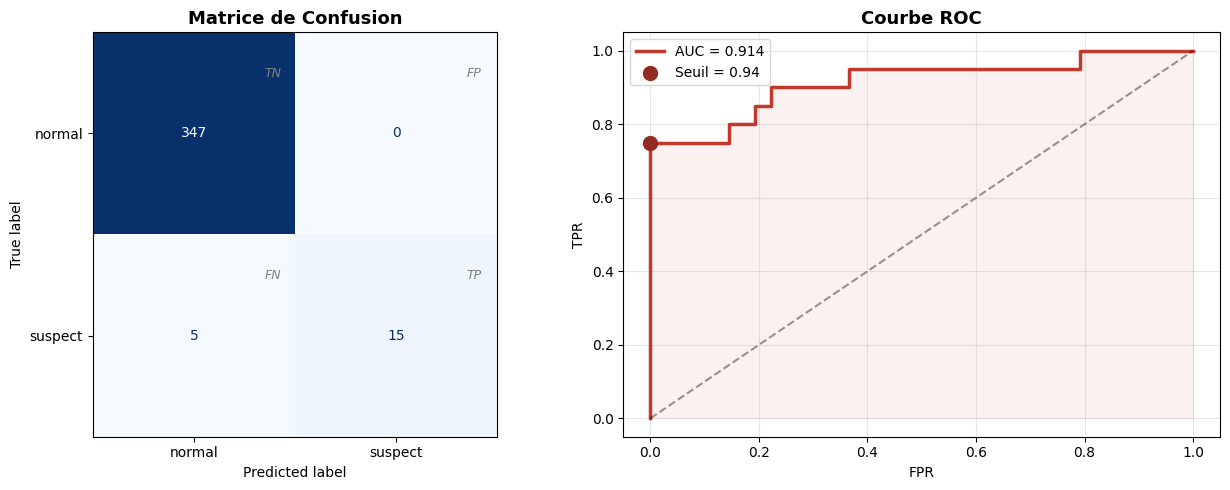

AUC-ROC   : 0.9141
Precision : 1.0000
Recall    : 0.7500
FP : 0  |  FN : 5


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['normal', 'suspect'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Matrice de Confusion", fontweight='bold', fontsize=13)
tn, fp, fn, tp = cm.ravel()
for (i,j), lbl in [((0,0),'TN'),((0,1),'FP'),((1,0),'FN'),((1,1),'TP')]:
    axes[0].text(j+0.35, i-0.28, lbl, fontsize=9, color='gray', style='italic')

roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, '#c0392b', lw=2.5, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].fill_between(fpr, tpr, alpha=0.07, color='#c0392b')
axes[1].scatter(fpr[j_idx], tpr[j_idx], s=100, color='#922b21', zorder=5,
                label=f'Seuil = {BEST_THRESH:.2f}')
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("Courbe ROC", fontweight='bold', fontsize=13)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC-ROC   : {roc_auc:.4f}")
print(f"Precision : {tp/(tp+fp) if (tp+fp)>0 else 0:.4f}")
print(f"Recall    : {tp/(tp+fn) if (tp+fn)>0 else 0:.4f}")
print(f"FP : {fp}  |  FN : {fn}")

## Etape 8 - Courbes d'apprentissage

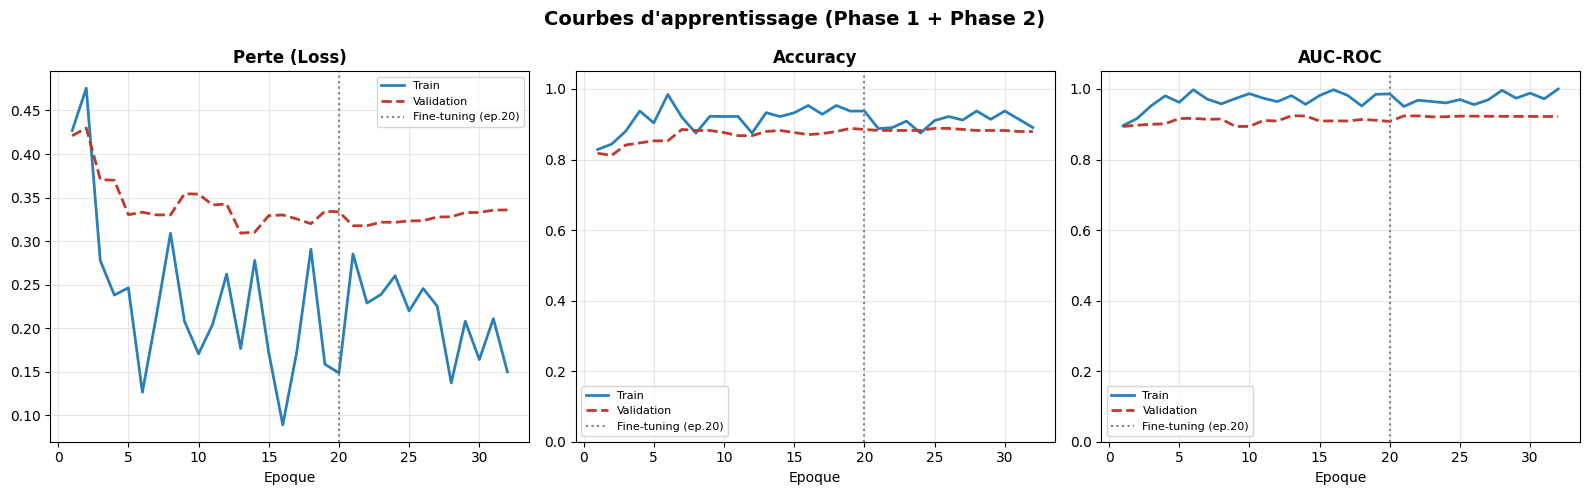

In [ ]:
# Concatener les deux phases
def concat_hist(h1, h2, metric):
    v1 = h1.history.get(metric, [])
    v2 = h2.history.get(metric, [])
    return v1 + v2

metrics_plot = ['loss', 'accuracy', 'auc']
titles_plot  = ['Perte (Loss)', 'Accuracy', 'AUC-ROC']
ylims_plot   = [None, [0, 1.05], [0, 1.05]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Courbes d'apprentissage (Phase 1 + Phase 2)", fontsize=14, fontweight='bold')

for ax, metric, title, ylim in zip(axes, metrics_plot, titles_plot, ylims_plot):
    tr  = concat_hist(history_p1, history_p2, metric)
    val = concat_hist(history_p1, history_p2, f'val_{metric}')
    ep  = range(1, len(tr) + 1)
    sep = len(history_p1.history[metric])  # separation phase 1 / phase 2

    ax.plot(ep, tr,  '#2980b9', lw=2, label='Train')
    ax.plot(ep, val, '#c0392b', lw=2, ls='--', label='Validation')
    ax.axvline(sep, color='gray', ls=':', lw=1.5, label=f'Fine-tuning (ep.{sep})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Epoque")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    if ylim: ax.set_ylim(ylim)

plt.tight_layout()
plt.savefig("courbes_apprentissage.png", dpi=150, bbox_inches='tight')
plt.show()

## Etape 9 - Detection sur video

Chargement depuis Google Drive. Inference par resize de la frame entiere en 96x96
(une seule passe CNN par frame — rapide).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

VIDEO_EXTENSIONS = ('.mp4', '.avi', '.mov', '.mkv', '.MP4', '.AVI', '.MOV')
video_files = []
for root, dirs, files in os.walk('/content/drive/MyDrive/Colab Notebooks/Video voleur'):
    for f in files:
        if f.endswith(VIDEO_EXTENSIONS):
            video_files.append(os.path.join(root, f))

if not video_files:
    print("Aucune video trouvee dans Google Drive.")
else:
    print(f"{len(video_files)} video(s) trouvee(s) :")
    for i, v in enumerate(video_files):
        size_mb = os.path.getsize(v) / 1024**2
        print(f"  [{i}]  {os.path.basename(v)}  ({size_mb:.1f} MB)  {v}")

Mounted at /content/drive
13 video(s) trouvee(s) :
  [0]  20260317_202223.mp4  (19.5 MB)  /content/drive/MyDrive/Colab Notebooks/Video voleur/20260317_202223.mp4
  [1]  20260317_202159.mp4  (7.9 MB)  /content/drive/MyDrive/Colab Notebooks/Video voleur/20260317_202159.mp4
  [2]  20260317_202135.mp4  (6.3 MB)  /content/drive/MyDrive/Colab Notebooks/Video voleur/20260317_202135.mp4
  [3]  20260317_202100.mp4  (18.3 MB)  /content/drive/MyDrive/Colab Notebooks/Video voleur/20260317_202100.mp4
  [4]  20260317_202027.mp4  (24.7 MB)  /content/drive/MyDrive/Colab Notebooks/Video voleur/20260317_202027.mp4
  [5]  20260317_201742.mp4  (28.5 MB)  /content/drive/MyDrive/Colab Notebooks/Video voleur/20260317_201742.mp4
  [6]  20260317_201711.mp4  (23.1 MB)  /content/drive/MyDrive/Colab Notebooks/Video voleur/20260317_201711.mp4
  [7]  20260317_201623.mp4  (41.5 MB)  /content/drive/MyDrive/Colab Notebooks/Video voleur/20260317_201623.mp4
  [8]  20260317_201554.mp4  (47.5 MB)  /content/drive/MyDrive/C

In [ ]:
# Selectionner la video
VIDEO_IDX   = 6   # <- modifier si plusieurs videos
VIDEO_INPUT = video_files[VIDEO_IDX]
# Ou chemin direct : VIDEO_INPUT = "/content/drive/MyDrive/dossier/video.mp4"

cap = cv2.VideoCapture(VIDEO_INPUT)
FPS_IN   = cap.get(cv2.CAP_PROP_FPS)
N_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W_VID    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_VID    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"Video : {os.path.basename(VIDEO_INPUT)}")
print(f"  Resolution : {W_VID}x{H_VID}")
print(f"  FPS        : {FPS_IN:.1f}")
print(f"  Duree      : {N_FRAMES / FPS_IN:.1f}s")

Video : 20260317_201711.mp4
  Resolution : 2160x3840
  FPS        : 60.0
  Duree      : 4.4s


In [ ]:
FRAME_SKIP    = 5
DETECT_THRESH = BEST_THRESH
PREVIEW_LIMIT = 16
VIDEO_OUTPUT  = "/content/output_detection.mp4"
DRIVE_OUTPUT  = os.path.join(os.path.dirname(VIDEO_INPUT),
                              "output_" + os.path.basename(VIDEO_INPUT))

def annotate_frame(frame_bgr, prob, thr, ts):
    out  = frame_bgr.copy()
    H, W = out.shape[:2]
    is_suspect = prob >= thr

    if is_suspect:
        cv2.rectangle(out, (3, 3), (W-3, H-3), (0, 0, 200), 4)
        overlay = out.copy()
        cv2.rectangle(overlay, (0,0), (W,H), (0,0,120), -1)
        cv2.addWeighted(overlay, 0.06, out, 0.94, 0, out)

    bar_w = int(W * prob)
    bar_color = (0,0,200) if is_suspect else (0,180,0)
    cv2.rectangle(out, (0, 0), (W, 18), (30,30,30), -1)
    cv2.rectangle(out, (0, 0), (bar_w, 18), bar_color, -1)
    status = f"SUSPECT {prob:.0%}" if is_suspect else f"Normal  {prob:.0%}"
    cv2.putText(out, status, (6, 14),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    cv2.putText(out, f"{ts:.1f}s", (W-60, H-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (160,160,160), 1)
    return out

cap    = cv2.VideoCapture(VIDEO_INPUT)
fps_out = max(1.0, FPS_IN / FRAME_SKIP)
fourcc  = cv2.VideoWriter_fourcc(*'mp4v')
writer  = cv2.VideoWriter(VIDEO_OUTPUT, fourcc, fps_out, (W_VID, H_VID))

frame_idx = 0
alert_count = 0
alert_times = []
all_probs   = []
preview_frames = []

print(f"Analyse en cours (seuil={DETECT_THRESH:.2f}, skip={FRAME_SKIP})...")

while True:
    ret, frame_bgr = cap.read()
    if not ret: break
    if frame_idx % FRAME_SKIP != 0:
        frame_idx += 1; continue

    frame_rgb   = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    frame_small = cv2.resize(frame_rgb, (IMG_SIZE, IMG_SIZE))
    inp         = np.expand_dims(frame_small.astype(np.float32) / 255.0, 0)
    prob        = float(model.predict(inp, verbose=0)[0][0])

    ts = frame_idx / FPS_IN
    all_probs.append(prob)
    if prob >= DETECT_THRESH:
        alert_count += 1
        alert_times.append(ts)

    frame_out = annotate_frame(frame_bgr, prob, DETECT_THRESH, ts)
    writer.write(frame_out)

    if prob >= DETECT_THRESH and len(preview_frames) < PREVIEW_LIMIT:
        preview_frames.append((frame_out.copy(), ts, prob))

    frame_idx += 1

cap.release()
writer.release()

import shutil
shutil.copy(VIDEO_OUTPUT, DRIVE_OUTPUT)

print(f"Video annotee : {VIDEO_OUTPUT}")
print(f"Copie Drive   : {DRIVE_OUTPUT}")
print(f"Frames analysees : {len(all_probs)}")
print(f"Alertes          : {alert_count}")
if all_probs:
    print(f"Score moyen      : {np.mean(all_probs):.3f}")
    print(f"Score max        : {max(all_probs):.3f}")

Analyse en cours (seuil=0.94, skip=5)...
Video annotee : /content/output_detection.mp4
Copie Drive   : /content/drive/MyDrive/Colab Notebooks/Video voleur/output_20260317_201711.mp4
Frames analysees : 53
Alertes          : 11
Score moyen      : 0.497
Score max        : 0.999


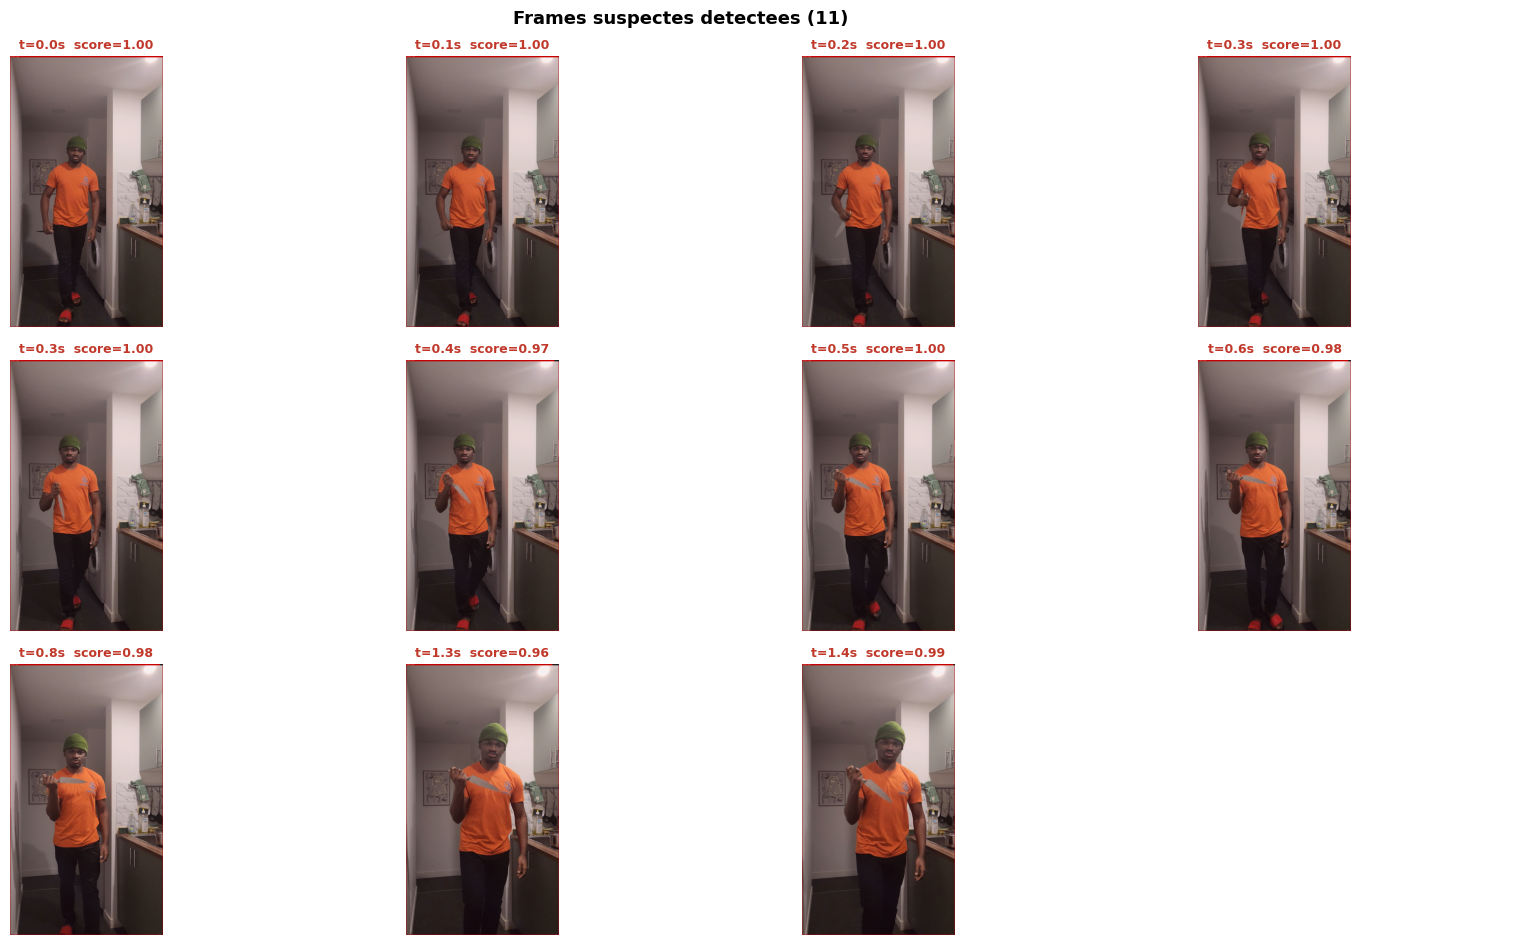

In [ ]:
# Apercu des frames suspectes
if not preview_frames:
    print("Aucune detection.")
    print(f"Score max observe : {max(all_probs):.3f}  (seuil={DETECT_THRESH:.3f})")
    print("Si necessaire : DETECT_THRESH = 0.35  puis relancer la cellule d'analyse")
else:
    n = len(preview_frames)
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 3.2))
    fig.suptitle(f"Frames suspectes detectees ({n})", fontsize=13, fontweight='bold')

    if rows == 1 and cols == 1: axes = np.array([[axes]])
    elif rows == 1: axes = axes[np.newaxis, :]
    elif cols == 1: axes = axes[:, np.newaxis]

    for i, (frame_bgr, ts, prob) in enumerate(preview_frames):
        r, c = divmod(i, cols)
        ax = axes[r][c]
        ax.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(f"t={ts:.1f}s  score={prob:.2f}",
                     fontsize=9, color='#c0392b', fontweight='bold')
        for spine in ax.spines.values():
            spine.set_edgecolor('#c0392b'); spine.set_linewidth(2.5)
        ax.axis('off')
    for i in range(n, rows * cols):
        r, c = divmod(i, cols)
        axes[r][c].axis('off')

    plt.tight_layout()
    plt.savefig("apercu_detections.png", dpi=150, bbox_inches='tight')
    plt.show()

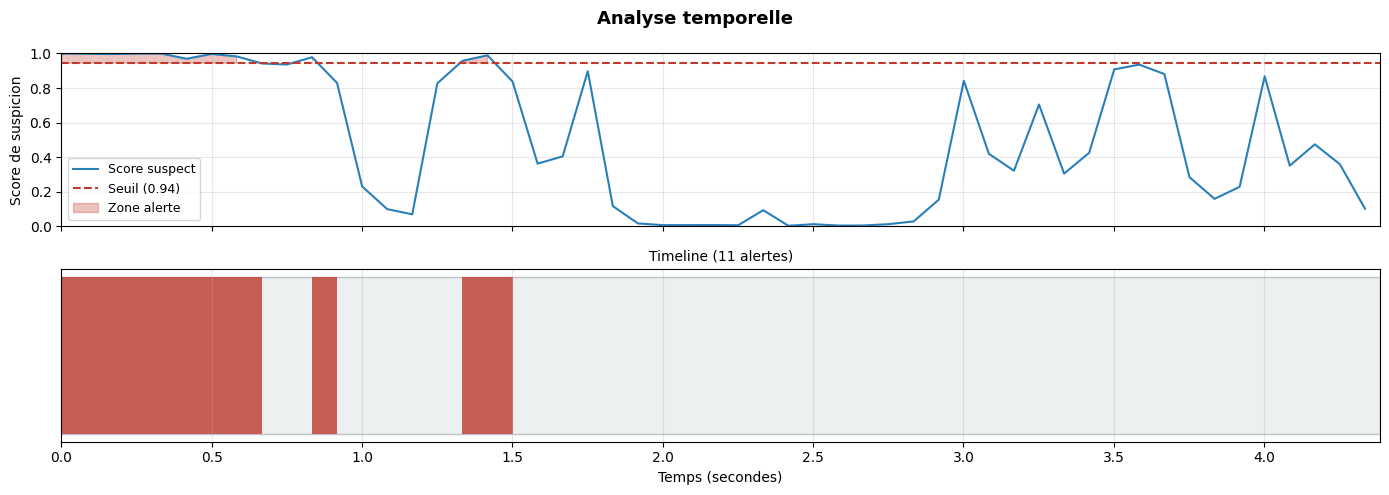

In [ ]:
# Evolution du score sur toute la video + timeline
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
fig.suptitle("Analyse temporelle", fontweight='bold', fontsize=13)

times = [i * FRAME_SKIP / FPS_IN for i in range(len(all_probs))]

axes[0].plot(times, all_probs, '#2980b9', lw=1.5, label='Score suspect')
axes[0].axhline(DETECT_THRESH, color='#c0392b', ls='--', lw=1.5,
                label=f'Seuil ({DETECT_THRESH:.2f})')
axes[0].fill_between(times, all_probs, DETECT_THRESH,
                     where=[p >= DETECT_THRESH for p in all_probs],
                     alpha=0.3, color='#c0392b', label='Zone alerte')
axes[0].set_ylabel("Score de suspicion")
axes[0].set_ylim(0, 1); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

duration_total = frame_idx / FPS_IN
axes[1].barh(0, duration_total, height=0.4, color='#ecf0f1', edgecolor='#bdc3c7')
for t in alert_times:
    axes[1].barh(0, FRAME_SKIP / FPS_IN, left=t, height=0.4,
                 color='#c0392b', alpha=0.8)
axes[1].set_xlim(0, duration_total)
axes[1].set_xlabel("Temps (secondes)")
axes[1].set_yticks([])
axes[1].set_title(f"Timeline ({alert_count} alertes)", fontsize=10)
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("timeline.png", dpi=150, bbox_inches='tight')
plt.show()

## Bilan

| Point | v3/v4 (CNN scratch) | v5 (MobileNetV2) |
|---|---|---|
| Architecture | CNN 3-4 blocs from scratch | MobileNetV2 pre-entraine ImageNet |
| Parametres entrainables | ~175K - 500K | ~260K (tete) puis fine-tuning |
| Entrainement | 1 phase | Phase 1 (tete) + Phase 2 (fine-tuning) |
| Augmentation | Aggressive (noir/blanc) | Conservative (rotation, flip, zoom) |
| Dataset | Thief v2 (human/suspicion) | Thief v1 (8 classes) |
| Fuite de donnees | Re-split global | Splits natifs conserves |

### Pourquoi MobileNetV2 est justifie
Le CNN from scratch atteignait AUC ~0.61-0.68 parce qu'il devait apprendre les
features visuelles de base (bords, textures, formes) en plus de la tache de
classification, avec un dataset de taille moderee. MobileNetV2 pre-entraine
possede deja ces features — il ne reste qu'a apprendre a les combiner pour
distinguer normal/suspect.